📊 DATASET
    Study_Hours  Attendance
0           1.0          50
1           2.0          55
2           2.5          60
3           3.0          65
4           3.5          68
5           4.0          70
6           6.0          80
7           6.5          82
8           7.0          85
9           8.0          90
10          8.5          92
11          9.0          95

📈 WCSS VALUES
K = 1 → WCSS = 24.00
K = 2 → WCSS = 4.15
K = 3 → WCSS = 2.39
K = 4 → WCSS = 0.81
K = 5 → WCSS = 0.48
K = 6 → WCSS = 0.37
K = 7 → WCSS = 0.27
K = 8 → WCSS = 0.16
K = 9 → WCSS = 0.08
K = 10 → WCSS = 0.06


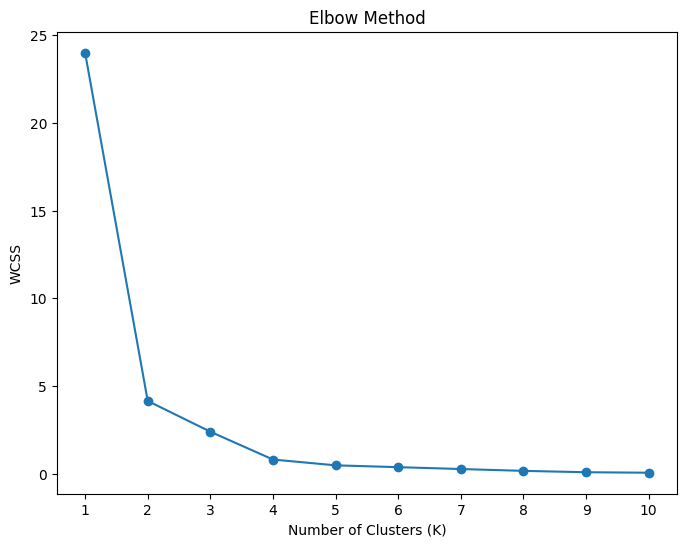


✅ OPTIMAL K: 3

📌 FINAL CLUSTERS
    Study_Hours  Attendance  Cluster
0           1.0          50        2
1           2.0          55        2
2           2.5          60        2
3           3.0          65        0
4           3.5          68        0
5           4.0          70        0
6           6.0          80        1
7           6.5          82        1
8           7.0          85        1
9           8.0          90        1
10          8.5          92        1
11          9.0          95        1


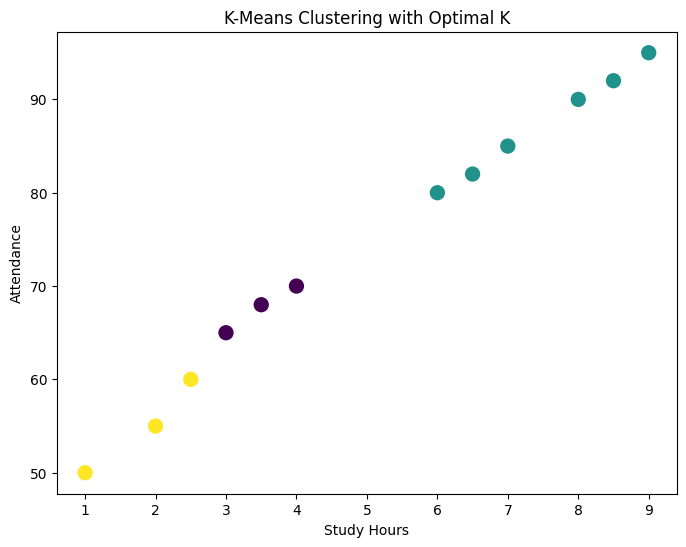

In [1]:
# =====================================================
# 📈 Day 23 - Elbow Method & Optimal K
# =====================================================

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 1. Create Dataset
data = {
    "Study_Hours": [1, 2, 2.5, 3, 3.5, 4, 6, 6.5, 7, 8, 8.5, 9],
    "Attendance": [50, 55, 60, 65, 68, 70, 80, 82, 85, 90, 92, 95]
}

df = pd.DataFrame(data)

print("📊 DATASET")
print(df)

# 2. Select Features
X = df[["Study_Hours", "Attendance"]]

# 3. Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. Calculate WCSS for Different K Values
wcss = []

for k in range(1, 11):
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(X_scaled)
    wcss.append(model.inertia_)

print("\n📈 WCSS VALUES")

for k, value in zip(range(1, 11), wcss):
    print(f"K = {k} → WCSS = {value:.2f}")

# 5. Plot Elbow Curve
plt.figure(figsize=(8, 6))

plt.plot(
    range(1, 11),
    wcss,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.xticks(range(1, 11))
plt.show()

# 6. Apply Optimal K
optimal_k = 3

final_model = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

df["Cluster"] = final_model.fit_predict(X_scaled)

print("\n✅ OPTIMAL K:", optimal_k)

print("\n📌 FINAL CLUSTERS")
print(df)

# 7. Visualize Final Clusters
plt.figure(figsize=(8, 6))

plt.scatter(
    df["Study_Hours"],
    df["Attendance"],
    c=df["Cluster"],
    s=100
)

plt.xlabel("Study Hours")
plt.ylabel("Attendance")
plt.title("K-Means Clustering with Optimal K")
plt.show()